In [135]:
import pandas as pd
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, f1_score, ConfusionMatrixDisplay, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor


In [136]:
data_path = "student_dataset_10000_rows.csv"

df = pd.read_csv(data_path)

df.head(10)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
5,7,40,9,10,0,60,72.33,Placed
6,10,40,4,11,9,50,98.12,Placed
7,3,86,7,3,7,85,100.00,Placed
8,7,72,8,5,18,48,96.81,Placed
9,11,77,4,9,15,69,100.00,Placed


In [137]:
print("Is data null : ", df.isnull().sum().max())

Is data null :  0


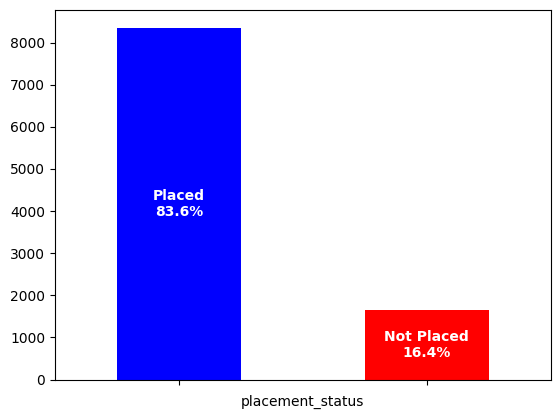

In [138]:
labels = ['Placed', 'Not Placed']
counts = df['placement_status'].value_counts().reindex(labels)

total = counts.sum()

percentage = (counts / total * 100).round(1)

ax = counts.plot.bar(color=['blue', 'red'])

bar_labels = [f"{label}\n{pct}%" for label, pct in zip(labels, percentage)] 

ax.bar_label(ax.containers[0], labels=bar_labels, label_type='center', color='white', rotation=0,fontsize=10, fontweight='bold')
ax.set_xticklabels([])
plt.show()


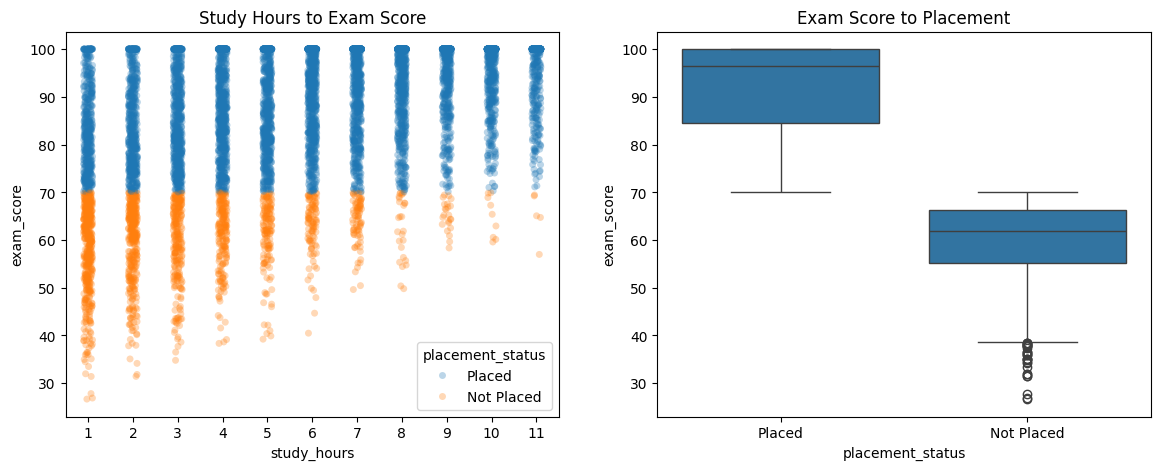

In [139]:
# Visualization compare of placement_status from study_hours and exam_score

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.stripplot(data=df, x='study_hours', y='exam_score', 
              hue='placement_status', alpha=0.3, jitter=True, ax=axes[0])

axes[0].set_title('Study Hours to Exam Score')
axes[0].set_xlabel('study_hours')
axes[0].set_ylabel('exam_score')

sns.boxplot(data=df, x='placement_status', y='exam_score', ax=axes[1], )

axes[1].set_title('Exam Score to Placement')
axes[1].set_xlabel('placement_status')
axes[1].set_ylabel('exam_score')

plt.show()

In [140]:
df.dtypes

study_hours                int64
attendance                 int64
sleep_hours                int64
internet_usage             int64
assignments_completed      int64
previous_score             int64
exam_score               float64
placement_status             str
dtype: object

In [141]:
# Preprocessing step 

dfe = df.copy()

dfe['placement_status'] = dfe['placement_status'].map({"Placed" : 0, "Not Placed" : 1})

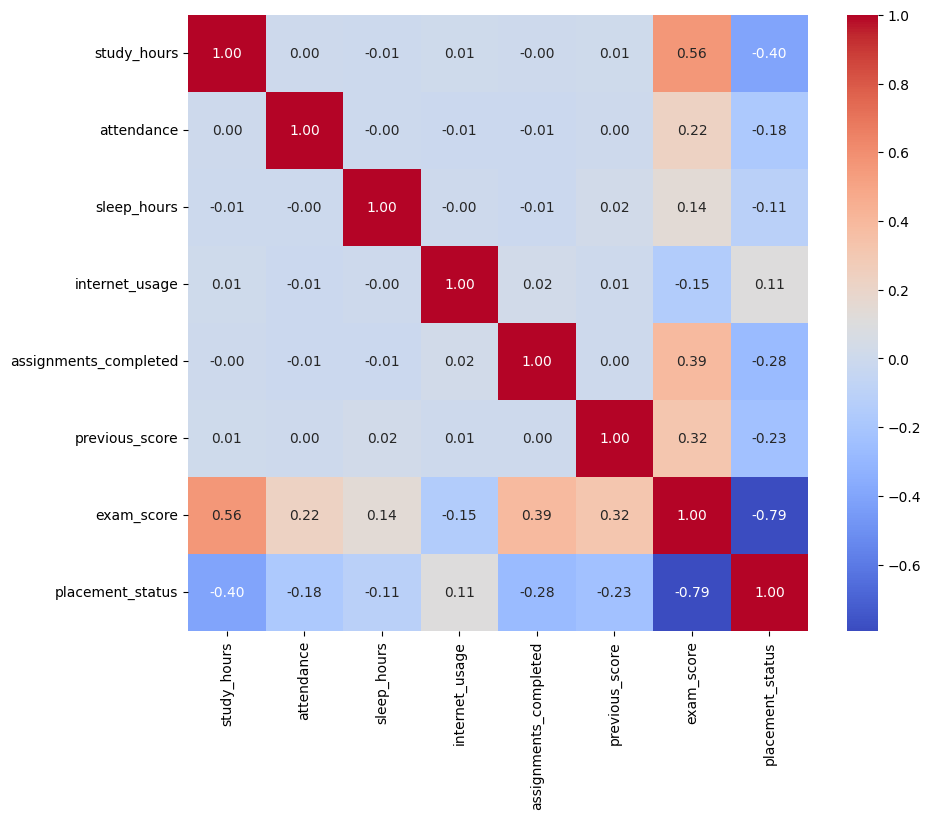

In [142]:
plt.figure(figsize=(10,8))

sns.heatmap(dfe.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.show()

In [143]:
dfe.dtypes

study_hours                int64
attendance                 int64
sleep_hours                int64
internet_usage             int64
assignments_completed      int64
previous_score             int64
exam_score               float64
placement_status           int64
dtype: object

In [144]:
# Preprocessing step to used for training

X = dfe.drop(['placement_status', 'exam_score'], axis=1)

y_reg, y_clf = dfe['exam_score'], dfe['placement_status']

# Train and test for regression 
X_train_reg, X_valid_reg, y_train_reg, y_valid_reg = train_test_split(X, y_reg , train_size=0.2, test_size=0.2, random_state=42)

# Train and test for classifier
X_train_clf, X_valid_clf, y_train_clf, y_valid_clf = train_test_split(X, y_clf, train_size=0.2, test_size=0.2, random_state=42)

print("The result of regression train & test size")
print("-"*20)
print("Train size : ", len(y_train_reg))
print("Test size : ", len(y_valid_reg))
print("-"*20)
print("Train size : ", len(y_train_clf))
print("Test size : ", len(y_valid_clf))

The result of regression train & test size
--------------------
Train size :  2000
Test size :  2000
--------------------
Train size :  2000
Test size :  2000



LinearRegression score 
 MAE score : 6.929473224874703 
 R2 score :  66.23%

DecisionTreeRegressor score 
 MAE score : 7.2412459775052 
 R2 score :  53.95%

RandomForestRegressor score 
 MAE score : 6.1065272051026085 
 R2 score :  69.29%

XGBRegressor score 
 MAE score : 7.051304473648072 
 R2 score :  60.19%


Text(0, 0.5, 'R2')

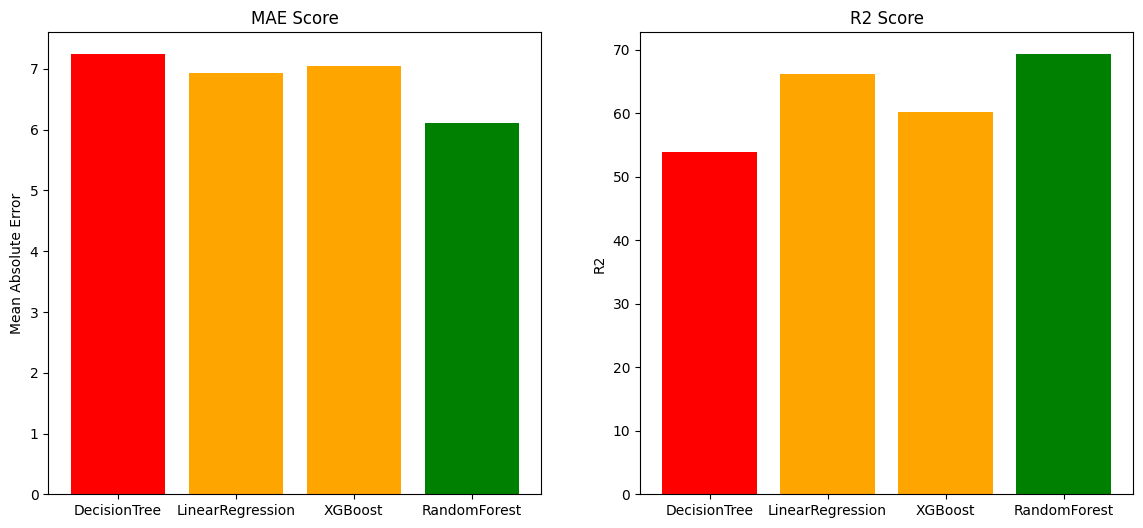

In [145]:
# Train and Test Using XGBRegressor, LinearRegressor, RandomForestRegressor

models = {
    "LinearRegression" : LinearRegression(),
    "DecisionTreeRegressor" : DecisionTreeRegressor(max_depth=10, random_state=42, min_samples_leaf=2, min_samples_split=20),
    "RandomForestRegressor" : RandomForestRegressor(max_depth=10 , n_estimators=200, random_state=42, min_samples_split=2, min_samples_leaf=1),
    "XGBRegressor" : XGBRegressor(n_estimators=100, learning_rate=0.5, random_state=2),

}

for name, model in models.items():
    model.fit(X_train_reg, y_train_reg)
    y_preds = model.predict(X_valid_reg)
    mae = mean_absolute_error(y_valid_reg, y_preds)
    r2 = r2_score(y_valid_reg, y_preds)
    print(f"\n{name} score \n MAE score : {mae} \n R2 score : {r2 * 100 : .2f}%")

models = ['DecisionTree', 'LinearRegression', 'XGBoost', 'RandomForest']

mae_scores = [7.24, 6.93, 7.05, 6.11]
r2_scores = [53.95, 66.23, 60.19, 69.29]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].set_title("MAE Score")
axes[0].bar(models, mae_scores, color=['red', 'orange', 'orange', 'green'])
axes[0].set_ylabel("Mean Absolute Error")

axes[1].set_title("R2 Score")
axes[1].bar(models, r2_scores, color=['red', 'orange', 'orange', 'green'])
axes[1].set_ylabel("R2")

